# Performance Analysis - Study 3

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats

## Loading the data

In [2]:
df = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [3]:
start_date = '2023-07-01'
end_date = '2024-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [ ]:
def calculate_sharpe_ratio(row):
    if (row['portfolio_std_dev'] == 0) & (row['portfolio_return'] == 0):
        return np.nan
    sharpe = (row['portfolio_return'] - risk_free_rate) / row['portfolio_std_dev']
    return sharpe

def get_market_data(tickers):
    for ticker in tickers:
        try:
            prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
            market_data[ticker] = prices
        except:
            market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index) 

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())
    portfolio_df = pd.DataFrame(columns=['ai', 'age', 'risk-taking', 'cond', 'iteration', 'portfolio_return', 'portfolio_std_dev'])
    grouped = df.groupby(group_cols)
    
    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
            
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate the cumulative portfolio return
        cumulative_returns = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        weights.index = cumulative_returns.index
        portfolio_return = (cumulative_returns * weights).sum()

        # Calculate the portfolio volatilty
        returns_df = prices_df.pct_change()
        cov_matrix = returns_df.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        portfolio_df.loc[len(portfolio_df)] = {
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'cond': name[3],
            'iteration': name[4],
            'portfolio_return': portfolio_return,
            'portfolio_std_dev': portfolio_std_dev
        }
    return portfolio_df
        
group_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration']    
portfolio_df = get_portfolio_data(df, group_cols)
portfolio_df['sharpe'] = portfolio_df.apply(calculate_sharpe_ratio, axis=1)
portfolio_df.to_csv('./data/performance_features.csv')


## Analysis

In [4]:
portfolio_df = pd.read_csv('./data/performance_features.csv', index_col=0)
portfolio_df['risk-taking'] = portfolio_df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolio_df['cond'] = portfolio_df['cond'].replace({'control':'Control prompt', 'engineered':'Goal prompt'})
portfolio_df['portfolio_std_dev'] *= 100 # in %
portfolio_df['portfolio_return'] *= 100 # in %

In [5]:
label_dict = {'cond':'Condition', 'age':'Age', 'risk-taking':'Risk Tendency'}

def fetch_benchmark_data(ticker):
    prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    cumulative_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    returns_df = prices.pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    return cumulative_return, std_dev, sharpe

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups, observed=False):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')
    
def show_mean_errplot(raw, column, label, benchmark, benchmark_label, group1, group2=None):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
    
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(5, 4), color=colors, zorder=2)
    ax.axhline(y=benchmark, color='black', linestyle='--', zorder=4)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)
    
    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/performance/{group1}{group2_label}-{label}.png', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    

In [6]:
benchmark_return, benchmark_std, benchmark_sharpe = fetch_benchmark_data('VT')
benchmark_return *= 100 # in %
benchmark_std *= 100 # in %

[*********************100%%**********************]  1 of 1 completed


### Portfolio Return

               sum_sq     df           F        PR(>F)
label     2384.950542    1.0  135.566036  1.172719e-23
Residual  3131.471637  178.0         NaN           NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj  lower   upper  reject
----------------------------------------------------------------
Control prompt Goal prompt    -7.28   0.0 -8.5139 -6.0462   True
----------------------------------------------------------------
group: ('Control prompt',) got t: -0.6207905451782375 p_value: 0.5363 dfs: 89 benchmark: 7.0324
group: ('Goal prompt',) got t: -14.689940081442794 p_value: 0.0 dfs: 89 benchmark: 7.0324
means:
cond
Control prompt    6.8086
Goal prompt      -0.4714
Name: portfolio_return, dtype: float64
stds:
cond
Control prompt    3.4207
Goal prompt       4.8460
Name: portfolio_return, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: portfolio_return, dtype: int64


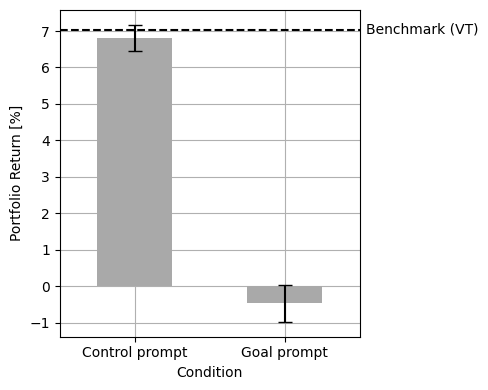

In [7]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond')

               sum_sq     df         F    PR(>F)
label      153.145575    2.0  2.527071  0.082772
Residual  5363.276604  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low    2.182  0.079 -0.1934 4.5574  False
  high medium   0.5833 0.8308 -1.7921 2.9587  False
   low medium  -1.5987 0.2523 -3.9741 0.7767  False
---------------------------------------------------
group: ('low',) got t: -11.387934821472674 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: ('medium',) got t: -5.3529562811752225 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: ('high',) got t: -5.2015249751301065 p_value: 0.0 dfs: 59 benchmark: 7.0324
means:
risk-taking
low       4.4288
medium    2.8301
high      2.2468
Name: portfolio_return, dtype: float64
stds:
risk-taking
low       1.7710
medium    6.0809
high      7.1266
Name: portfolio_return, dtype: float64
risk-taking
low       

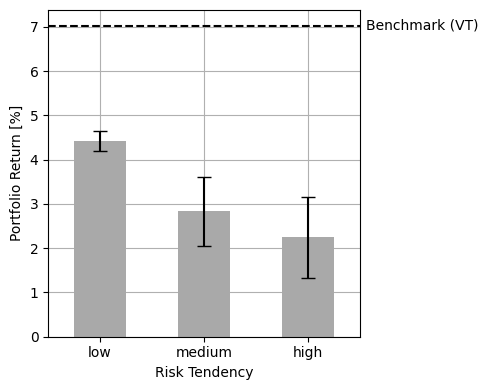

In [8]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]',  benchmark_return, 'Benchmark (VT)', 'risk-taking')

                sum_sq     df             F   PR(>F)
label     7.713982e-08    1.0  2.489093e-09  0.99996
Residual  5.516422e+03  178.0           NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.1635 0.9859 -2.2454 2.5723  False
    15     50   0.0148 0.9999 -2.3941 2.4237  False
    30     50  -0.1487 0.9883 -2.5575 2.2602  False
---------------------------------------------------
group: (15,) got t: -6.24532554413493 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: (30,) got t: -4.653068605259333 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: (50,) got t: -5.470305474571328 p_value: 0.0 dfs: 59 benchmark: 7.0324
means:
age
15    3.1092
30    3.2726
50    3.1240
Name: portfolio_return, dtype: float64
stds:
age
15    4.8660
30    6.2590
50    5.5344
Name: portfolio_return, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_return, dtype: int64

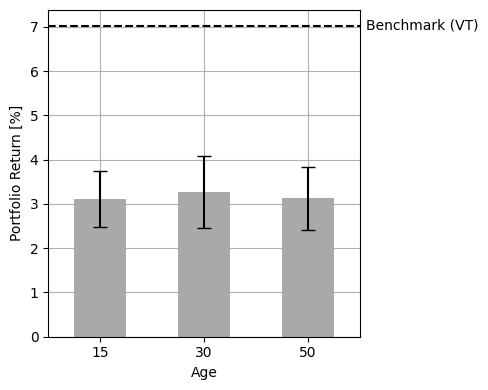

In [9]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'age')

               sum_sq     df          F        PR(>F)
label     3912.176917    5.0  84.864677  8.099523e-45
Residual  1604.245262  174.0        NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)    (Control prompt, low)  -3.9462    0.0  -6.2055  -1.687   True
  (Control prompt, high) (Control prompt, medium)   0.0062    1.0  -2.2531  2.2655  False
  (Control prompt, high)      (Goal prompt, high) -11.7503    0.0 -14.0095  -9.491   True
  (Control prompt, high)       (Goal prompt, low)    -3.44 0.0003  -5.6993 -1.1807   True
  (Control prompt, high)    (Goal prompt, medium) -10.5899    0.0 -12.8491 -8.3306   True
   (Control prompt, low) (Control prompt, medium)   3.9525    0.0   1.6932  6.2118   True
   (Control prompt, low)    

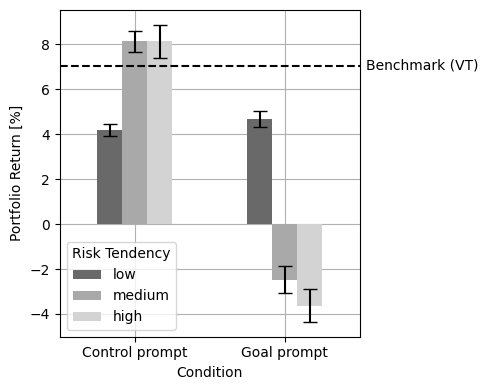

In [10]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond', 'risk-taking')

### Portfolio Volatility

             sum_sq     df         F    PR(>F)
label      0.003538    1.0  0.018327  0.892468
Residual  34.360929  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower  upper  reject
----------------------------------------------------------------
Control prompt Goal prompt  -0.0089 0.8925 -0.1381 0.1204  False
----------------------------------------------------------------
group: ('Control prompt',) got t: 5.45936526135818 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: ('Goal prompt',) got t: 6.624030718142046 p_value: 0.0 dfs: 89 benchmark: 0.7562
means:
cond
Control prompt    1.0356
Goal prompt       1.0268
Name: portfolio_std_dev, dtype: float64
stds:
cond
Control prompt    0.4857
Goal prompt       0.3876
Name: portfolio_std_dev, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: portfolio_std_dev, dtype: int64


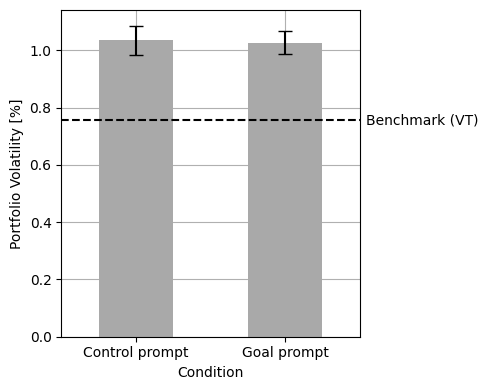

In [11]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond')

             sum_sq     df           F        PR(>F)
label     19.052706    2.0  110.122187  8.492249e-32
Residual  15.311760  177.0         NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  high    low  -0.7938   0.0 -0.9207 -0.6669   True
  high medium  -0.3361   0.0  -0.463 -0.2092   True
   low medium   0.4577   0.0  0.3308  0.5846   True
---------------------------------------------------
group: ('low',) got t: -7.797486520888283 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: ('medium',) got t: 7.541923681916418 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: ('high',) got t: 13.76300435350492 p_value: 0.0 dfs: 59 benchmark: 0.7562
means:
risk-taking
low       0.6140
medium    1.0718
high      1.4079
Name: portfolio_std_dev, dtype: float64
stds:
risk-taking
low       0.1412
medium    0.3241
high      0.3668
Name: portfolio_std_dev, dtype: float64
risk-taking
l

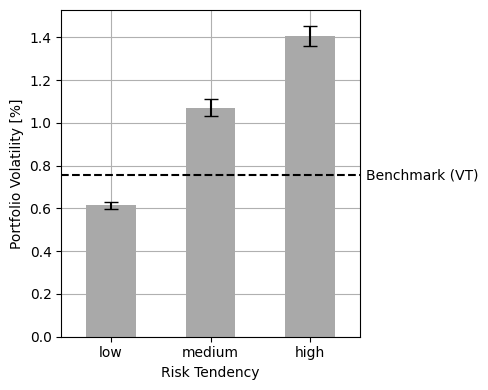

In [12]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'risk-taking')

             sum_sq     df         F    PR(>F)
label      0.091498    1.0  0.475201  0.491502
Residual  34.272969  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0037 0.9988 -0.1861 0.1935  False
    15     50  -0.0526 0.7901 -0.2424 0.1373  False
    30     50  -0.0562 0.7636 -0.2461 0.1336  False
---------------------------------------------------
group: (15,) got t: 5.101152360826908 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: (30,) got t: 4.82785584515519 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: (50,) got t: 4.614366945350797 p_value: 0.0 dfs: 59 benchmark: 0.7562
means:
age
15    1.0475
30    1.0512
50    0.9950
Name: portfolio_std_dev, dtype: float64
stds:
age
15    0.4424
30    0.4733
50    0.4008
Name: portfolio_std_dev, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_std_dev, dtype: int64


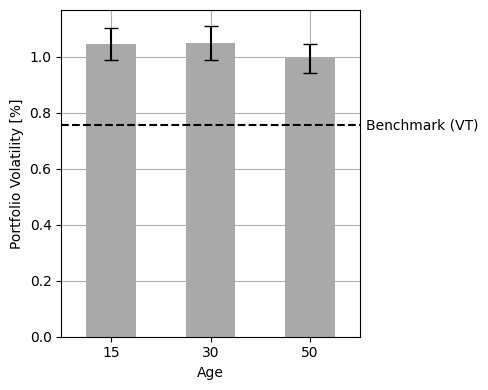

In [13]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'age')

             sum_sq     df          F        PR(>F)
label     21.203350    5.0  56.064893  1.666834e-34
Residual  13.161116  174.0        NaN           NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)    (Control prompt, low)  -1.0079    0.0 -1.2125 -0.8032   True
  (Control prompt, high) (Control prompt, medium)  -0.5821    0.0 -0.7867 -0.3775   True
  (Control prompt, high)      (Goal prompt, high)  -0.3156 0.0002 -0.5202 -0.1109   True
  (Control prompt, high)       (Goal prompt, low)  -0.8954    0.0    -1.1 -0.6907   True
  (Control prompt, high)    (Goal prompt, medium)  -0.4057    0.0 -0.6103  -0.201   True
   (Control prompt, low) (Control prompt, medium)   0.4258    0.0  0.2211  0.6304   True
   (Control prompt, low)      (Goal prompt,

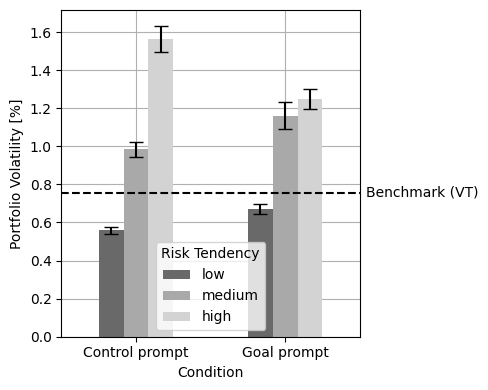

In [14]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond', 'risk-taking')

### Sharpe

In [15]:
print(portfolio_df.shape)
sharpe_df = portfolio_df.copy()
sharpe_df = sharpe_df.dropna()
print(sharpe_df.shape)

(180, 9)
(180, 9)


               sum_sq     df           F        PR(>F)
label     1492.500187    1.0  103.983764  1.607485e-19
Residual  2554.870324  178.0         NaN           NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj  lower   upper  reject
----------------------------------------------------------------
Control prompt Goal prompt  -5.7591   0.0 -6.8735 -4.6446   True
----------------------------------------------------------------
group: ('Control prompt',) got t: -4.301250458449132 p_value: 0.0 dfs: 89 benchmark: 3.6172
group: ('Goal prompt',) got t: -16.835517820945945 p_value: 0.0 dfs: 89 benchmark: 3.6172
means:
cond
Control prompt    2.0644
Goal prompt      -3.6946
Name: sharpe, dtype: float64
stds:
cond
Control prompt    3.4249
Goal prompt       4.1202
Name: sharpe, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: sharpe, dtype: int64


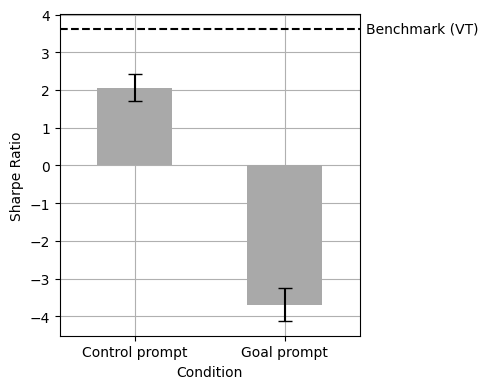

In [16]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond')

               sum_sq     df         F    PR(>F)
label      106.019292    2.0  2.380581  0.095453
Residual  3941.351218  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   1.8717 0.0788 -0.1646 3.9081  False
  high medium   0.7845 0.6343 -1.2518 2.8209  False
   low medium  -1.0872 0.4186 -3.1235 0.9491  False
---------------------------------------------------
group: ('low',) got t: -8.951302397668595 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: ('medium',) got t: -6.5089976862768815 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: ('high',) got t: -7.674611656766439 p_value: 0.0 dfs: 59 benchmark: 3.6172
means:
risk-taking
low       0.1712
medium   -0.9160
high     -1.7005
Name: sharpe, dtype: float64
stds:
risk-taking
low       2.9820
medium    5.3947
high      5.3672
Name: sharpe, dtype: float64
risk-taking
low       60
medium    60
high  

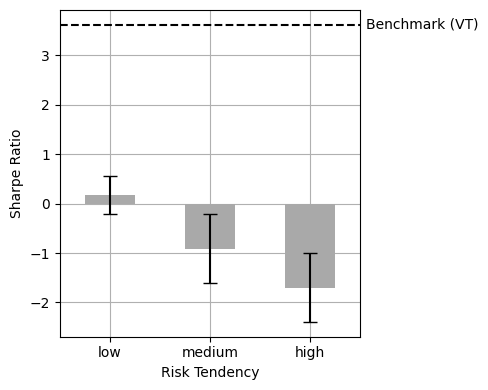

In [17]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F    PR(>F)
label        0.059816    1.0  0.002631  0.959152
Residual  4047.310695  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.2211 0.9652 -1.8419 2.2841  False
    15     50  -0.0227 0.9996 -2.0857 2.0403  False
    30     50  -0.2438 0.9579 -2.3068 1.8192  False
---------------------------------------------------
group: (15,) got t: -8.32328742878422 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: (30,) got t: -6.65673501242299 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: (50,) got t: -6.8337044843001475 p_value: 0.0 dfs: 59 benchmark: 3.6172
means:
age
15   -0.8813
30   -0.6602
50   -0.9039
Name: sharpe, dtype: float64
stds:
age
15    4.1865
30    4.9773
50    5.1247
Name: sharpe, dtype: float64
age
15    60
30    60
50    60
Name: sharpe, dtype: int64


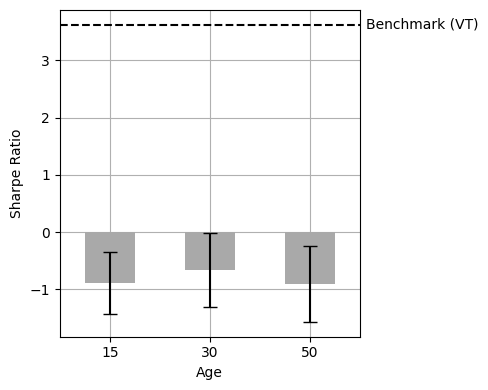

In [18]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'age')

               sum_sq     df         F        PR(>F)
label     2741.518487    5.0  73.05946  6.359271e-41
Residual  1305.852024  174.0       NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)    (Control prompt, low)  -3.2668 0.0001  -5.3052 -1.2285   True
  (Control prompt, high) (Control prompt, medium)   1.1769 0.5575  -0.8615  3.2152  False
  (Control prompt, high)      (Goal prompt, high)  -8.9232    0.0 -10.9616 -6.8848   True
  (Control prompt, high)       (Goal prompt, low)  -1.9129 0.0795  -3.9512  0.1255  False
  (Control prompt, high)    (Goal prompt, medium)   -8.531    0.0 -10.5694 -6.4927   True
   (Control prompt, low) (Control prompt, medium)   4.4437    0.0   2.4053  6.4821   True
   (Control prompt, low)      (

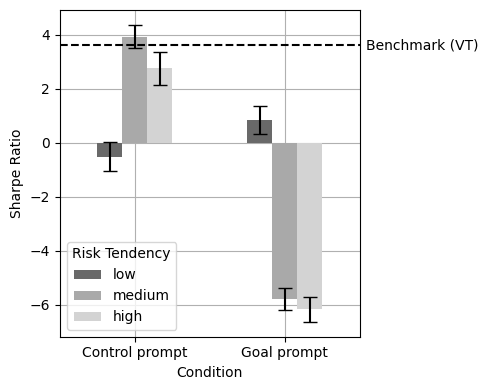

In [19]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond', 'risk-taking')